In [2]:
import pandas as pd

df = pd.read_csv("../data/superstore_sales.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Dataset shape: (10194, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [4]:
print(df.dtypes)

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object


In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df.dtypes[["Order Date", "Ship Date"]])

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Order date range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nTotal Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())

print("\nAverage Discount:", df["Discount"].mean())


Order date range:
2023-01-03 00:00:00 to 2026-12-30 00:00:00

Total Sales: 2326534.3543
Total Profit: 292296.8146
Total Quantity: 38654

Average Discount: 0.15538453992544635


In [8]:
region_summary = (
    df.groupby("Region")[["Sales", "Profit", "Quantity"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

region_summary

,Sales,Profit,Quantity
Region,,,
West,739813.6085,110798.8170,12466
East,691828.1680,94883.2603,11159
Central,503170.6728,39865.3070,8820
South,391721.9050,46749.4303,6209


In [9]:
region_summary["Profit Margin %"] = (
    region_summary["Profit"] / region_summary["Sales"] * 100
).round(2)

region_summary

,Sales,Profit,Quantity,Profit Margin %
Region,,,,
West,739813.6085,110798.8170,12466,14.98
East,691828.1680,94883.2603,11159,13.71
Central,503170.6728,39865.3070,8820,7.92
South,391721.9050,46749.4303,6209,11.93


In [10]:
discount_by_region = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Avg_Discount=("Discount", "mean")
      )
)

discount_by_region["Profit Margin %"] = (
    discount_by_region["Profit"] /
    discount_by_region["Sales"] * 100
).round(2)

discount_by_region.round(2)

,Sales,Profit,Avg_Discount,Profit Margin %
Region,,,,
Central,503170.67,39865.31,0.24,7.92
East,691828.17,94883.26,0.14,13.71
South,391721.90,46749.43,0.15,11.93
West,739813.61,110798.82,0.11,14.98


In [11]:
print("Correlation between Discount and Profit:")
print(df["Discount"].corr(df["Profit"]))

Correlation between Discount and Profit:
-0.21888187168877116


In [12]:
discount_summary = (
    df.groupby("Discount")
      .agg(
          Transactions=("Profit", "size"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_index()
)

discount_summary["Profit Margin %"] = (
    discount_summary["Profit"] /
    discount_summary["Sales"] * 100
).round(2)

discount_summary.round(2)

,Transactions,Sales,Profit,Profit Margin %
Discount,,,,
0.00,4925,1105323.79,326718.59,29.56
0.10,96,54952.50,9099.97,16.56
0.15,52,27558.52,1418.99,5.15
0.20,3706,773939.40,91079.95,11.77
0.30,230,104474.07,-10513.45,-10.06
0.32,27,14493.46,-2391.14,-16.50
0.40,207,116497.76,-23086.37,-19.82
0.45,11,5484.97,-2493.11,-45.45
0.50,66,58918.54,-20506.43,-34.80


In [1]:
discount_region = pd.crosstab(
    df["Region"],
    df["Discount"],
    normalize="index"
) * 100

discount_region.round(2)


NameError: name 'pd' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../data/superstore_sales.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [3]:
discount_region = pd.crosstab(
    df["Region"],
    df["Discount"],
    normalize="index"
) * 100

discount_region.round(2)

Discount,0.00,0.10,0.15,0.20,0.30,0.32,0.40,0.45,0.50,0.60,0.70,0.80
Region,,,,,,,,,,,,
Central,35.46,0.77,0.0,36.06,6.30,1.16,0.56,0.00,0.77,5.95,0.09,12.89
East,51.84,2.55,0.0,29.57,2.78,0.00,5.96,0.00,0.60,0.33,6.36,0.00
South,49.69,0.00,0.0,39.75,0.00,0.00,0.99,0.68,0.74,0.00,8.15,0.00
West,53.61,0.06,1.6,41.10,0.00,0.00,0.00,0.00,0.55,0.00,3.07,0.00


In [4]:
high_discount = (
    df[df["Discount"] >= 0.60]
    .groupby(["Category", "Sub-Category"])
    .agg(
        Transactions=("Profit", "size"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean")
    )
    .sort_values("Profit")
)

high_discount.round(2)

Transactions     Sales    Profit  Avg_Discount
Category        Sub-Category                                                
Office Supplies Binders                617  36194.45 -38562.28          0.74
Technology      Machines                23  15601.51 -19579.32          0.70
Office Supplies Appliances              67   3382.53  -8629.64          0.80
Furniture       Furnishings            147   7051.98  -6134.07          0.60
                Bookcases               17   2603.97  -4092.54          0.70
Office Supplies Art                      1     39.96    -23.98          0.60
                Paper                    1     14.00     -6.30          0.60
                Labels                   1      2.95     -2.06          0.70

In [5]:
central_high_discount = (
    df[
        (df["Region"] == "Central") &
        (df["Discount"] >= 0.60)
    ]
    .groupby(["Category", "Sub-Category"])
    .agg(
        Transactions=("Profit", "size"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean")
    )
    .sort_values("Profit")
)

central_high_discount.round(2)

Transactions     Sales    Profit  Avg_Discount
Category        Sub-Category                                                
Office Supplies Binders                236  13626.32 -21955.06           0.8
                Appliances              67   3382.53  -8629.64           0.8
Furniture       Furnishings            139   6658.70  -5950.96           0.6

In [6]:
central_binders = (
    df[
        (df["Region"] == "Central") &
        (df["Sub-Category"] == "Binders") &
        (df["Discount"] >= 0.60)
    ]
    .groupby("Product Name")
    .agg(
        Transactions=("Profit", "size"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean")
    )
    .sort_values("Profit")
)

central_binders.round(2)

,Transactions,Sales,Profit,Avg_Discount
Product Name,,,,
GBC DocuBind P400 Electric Binding System,2,3266.38,-5552.84,0.8
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,2,2287.78,-3431.67,0.8
Ibico EPK-21 Electric Binding System,1,1889.99,-2929.48,0.8
Ibico Hi-Tech Manual Binding System,4,914.97,-1601.20,0.8
GBC DocuBind TL300 Electric Binding System,1,896.99,-1480.03,0.8
...,...,...,...,...
Zipper Ring Binder Pockets,1,1.25,-1.93,0.8
Economy Binders,1,1.25,-1.93,0.8
Acco Economy Flexible Poly Round Ring Binder,1,1.04,-1.83,0.8


In [7]:
extreme_discount = df[df["Discount"] >= 0.60].copy()

extreme_discount["Year"] = extreme_discount["Order Date"].dt.year

year_summary = (
    extreme_discount
    .groupby("Year")
    .agg(
        Transactions=("Profit", "size"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean")
    )
)

year_summary["Profit Margin %"] = (
    year_summary["Profit"] / year_summary["Sales"] * 100
).round(2)

year_summary.round(2)

,Transactions,Sales,Profit,Avg_Discount,Profit Margin %
Year,,,,,
2023,168,10642.72,-13356.95,0.72,-125.50
2024,190,14654.02,-15819.71,0.72,-107.95
2025,225,17438.02,-20372.89,0.71,-116.83
2026,291,22156.59,-27480.63,0.72,-124.03


In [8]:
binder_discount = (
    df[df["Sub-Category"] == "Binders"]
    .groupby("Discount")
    .agg(
        Transactions=("Profit", "size"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_index()
)

binder_discount["Profit Margin %"] = (
    binder_discount["Profit"] /
    binder_discount["Sales"] * 100
).round(2)

binder_discount.round(2)

,Transactions,Sales,Profit,Profit Margin %
Discount,,,,
0.0,351,84450.10,40421.06,47.86
0.2,580,86710.33,29567.31,34.10
0.7,383,22596.84,-16626.65,-73.58
0.8,234,13597.61,-21935.63,-161.32


# Superstore Sales & Profitability Analysis

## 1. Dataset Overview

The dataset contains 10,194 sales transactions across 21 columns, covering the period from January 3, 2023 to December 30, 2026.

- Total Sales: $2,326,534.35
- Total Profit: $292,296.81
- Total Quantity: 38,654 units
- Overall Profit Margin: 12.56%
- Missing Values: None
- Duplicate Rows: None

## 2. Regional Profitability

The West region generated the highest sales ($739,813.61) and highest profit ($110,798.82), with a profit margin of 14.98%.

The Central region showed the weakest profitability, with $503,170.67 in sales but only $39,865.31 in profit, corresponding to a 7.92% profit margin.

## 3. Discount and Profitability

The average discount across all transactions was 15.54%.

Discount and profit showed a negative correlation of -0.2189, indicating a negative linear association between discount level and profit.

Regional analysis showed that Central had the highest average discount at approximately 24%, while also having the lowest regional profit margin.

## 4. Extreme Discounting

Transactions with discounts of 60% or higher generated aggregate losses in every year from 2023 through 2026.

These transactions had an average discount of approximately 71–72% and produced negative aggregate profit each year.

## 5. High-Discount Categories

At discounts of 60% or higher, major losses were concentrated in categories such as:

- Binders
- Machines
- Appliances
- Furnishings
- Bookcases

Within Central, high-discount Binders, Appliances, and Furnishings generated substantial aggregate losses.

## 6. Binder-Level Analysis

Within the Binders sub-category, profitability deteriorated sharply as discount levels increased:

| Discount | Profit Margin |
|---|---:|
| 0% | 47.86% |
| 20% | 34.10% |
| 70% | -73.58% |
| 80% | -161.32% |

This suggests a strong association between extreme discounting and deteriorating profitability within the Binders category.

## 7. Preliminary Business Finding

The analysis indicates that extreme discounting is associated with significant profitability deterioration, particularly in selected product categories and in the Central region.

Further analysis is required before making causal claims or recommending specific pricing-policy changes.

In [9]:
import sqlite3

conn = sqlite3.connect("../sql/superstore.db")

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully.")
print("Table: sales")

Database created successfully.
Table: sales


In [10]:
cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) FROM sales")
print("Rows in sales table:", cursor.fetchone()[0])

cursor.execute("PRAGMA table_info(sales)")
columns = cursor.fetchall()

print("\nColumns:")
for column in columns:
    print(column[1], "->", column[2])
    

Rows in sales table: 10194

Columns:
Row ID -> INTEGER
Order ID -> TEXT
Order Date -> TIMESTAMP
Ship Date -> TIMESTAMP
Ship Mode -> TEXT
Customer ID -> TEXT
Customer Name -> TEXT
Segment -> TEXT
Country/Region -> TEXT
City -> TEXT
State/Province -> TEXT
Postal Code -> TEXT
Region -> TEXT
Product ID -> TEXT
Category -> TEXT
Sub-Category -> TEXT
Product Name -> TEXT
Sales -> REAL
Quantity -> INTEGER
Discount -> REAL
Profit -> REAL


In [11]:
query = """
SELECT
    Region,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin_Pct
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

region_sql = pd.read_sql_query(query, conn)

region_sql

,Region,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_Pct
0,West,739813.6085,110798.8170,12466,14.98
1,East,691828.1680,94883.2603,11159,13.71
2,Central,503170.6728,39865.3070,8820,7.92
3,South,391721.9050,46749.4303,6209,11.93


In [12]:
query = """
SELECT
    Discount,
    COUNT(*) AS Transactions,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin_Pct
FROM sales
GROUP BY Discount
ORDER BY Discount;
"""

discount_sql = pd.read_sql_query(query, conn)

discount_sql

,Discount,Transactions,Total_Sales,Total_Profit,Profit_Margin_Pct
0,0.00,4925,1105323.79,326718.59,29.56
1,0.10,96,54952.50,9099.97,16.56
2,0.15,52,27558.52,1418.99,5.15
3,0.20,3706,773939.40,91079.95,11.77
4,0.30,230,104474.07,-10513.45,-10.06
5,0.32,27,14493.46,-2391.14,-16.50
6,0.40,207,116497.76,-23086.37,-19.82
7,0.45,11,5484.97,-2493.11,-45.45
8,0.50,66,58918.54,-20506.43,-34.80
9,0.60,149,7105.94,-6164.35,-86.75


In [13]:
query = """
SELECT
    CASE
        WHEN Discount >= 0.30 THEN 'High Discount (>=30%)'
        ELSE 'Standard Discount (<30%)'
    END AS Discount_Group,
    COUNT(*) AS Transactions,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin_Pct
FROM sales
GROUP BY Discount_Group
ORDER BY Discount_Group;
"""

discount_group_sql = pd.read_sql_query(query, conn)

discount_group_sql

,Discount_Group,Transactions,Total_Sales,Total_Profit,Profit_Margin_Pct
0,High Discount (>=30%),1415,364760.15,-136020.69,-37.29
1,Standard Discount (<30%),8779,1961774.20,428317.50,21.83


In [14]:
query = """
SELECT
    Region,
    CASE
        WHEN Discount >= 0.30 THEN 'High Discount (>=30%)'
        ELSE 'Standard Discount (<30%)'
    END AS Discount_Group,
    COUNT(*) AS Transactions,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin_Pct
FROM sales
GROUP BY Region, Discount_Group
ORDER BY Region, Discount_Group;
"""

region_discount_sql = pd.read_sql_query(query, conn)

region_discount_sql

,Region,Discount_Group,Transactions,Total_Sales,Total_Profit,Profit_Margin_Pct
0,Central,High Discount (>=30%),647,129193.20,-52444.23,-40.59
1,Central,Standard Discount (<30%),1688,373977.47,92309.54,24.68
2,East,High Discount (>=30%),479,147801.30,-42681.28,-28.88
3,East,Standard Discount (<30%),2507,544026.87,137564.54,25.29
4,South,High Discount (>=30%),171,70716.99,-24880.48,-35.18
5,South,Standard Discount (<30%),1449,321004.91,71629.91,22.31
6,West,High Discount (>=30%),118,17048.66,-16014.69,-93.94
7,West,Standard Discount (<30%),3135,722764.95,126813.51,17.55


In [15]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,

    ROUND(
        SUM(CASE WHEN Discount >= 0.30 THEN Profit ELSE 0 END),
        2
    ) AS High_Discount_Profit,

    ROUND(
        SUM(CASE WHEN Discount >= 0.30 THEN Sales ELSE 0 END),
        2
    ) AS High_Discount_Sales,

    ROUND(
        SUM(CASE WHEN Discount >= 0.30 THEN Profit ELSE 0 END)
        * 100.0 / SUM(Profit),
        2
    ) AS High_Discount_Profit_Share_Pct

FROM sales
WHERE Region = 'Central'
GROUP BY Region;
"""

central_impact_sql = pd.read_sql_query(query, conn)

central_impact_sql

,Region,Total_Sales,Total_Profit,High_Discount_Profit,High_Discount_Sales,High_Discount_Profit_Share_Pct
0,Central,503170.67,39865.31,-52444.23,129193.2,-131.55


In [16]:
from sklearn.linear_model import LinearRegression

X = df[["Discount"]]
y = df["Profit"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Discount coefficient:", model.coef_[0])
print("R²:", model.score(X, y))

Intercept: 67.00744005837976
Discount coefficient: -246.70422752361017
R²: 0.047909273753979464


In [17]:
import statsmodels.api as sm

X = df[["Discount"]]
X = sm.add_constant(X)
y = df["Profit"]

model_sm = sm.OLS(y, X).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     512.9
Date:                Wed, 26 Aug 2026   Prob (F-statistic):          7.97e-111
Time:                        23:04:31   Log-Likelihood:                -69758.
No. Observations:               10194   AIC:                         1.395e+05
Df Residuals:                   10192   BIC:                         1.395e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.0074      2.813     23.821      0.0

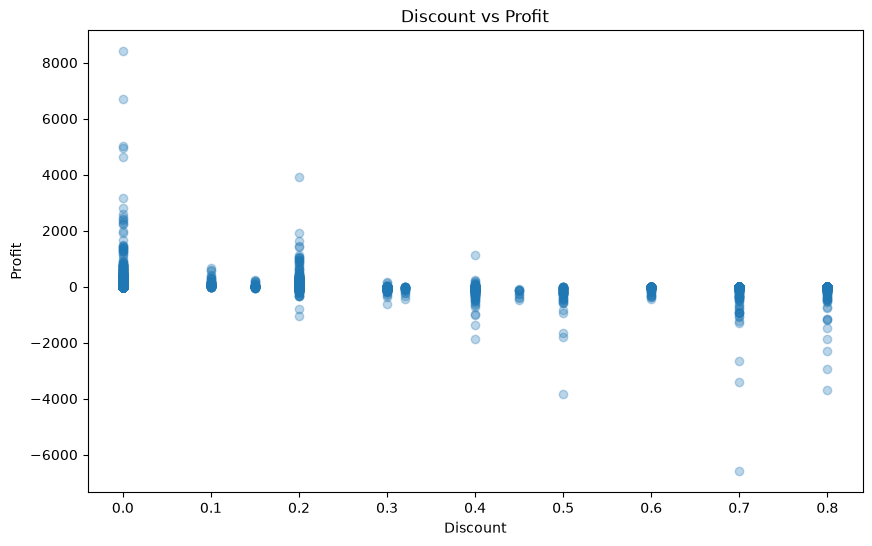

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["Discount"], df["Profit"], alpha=0.3)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

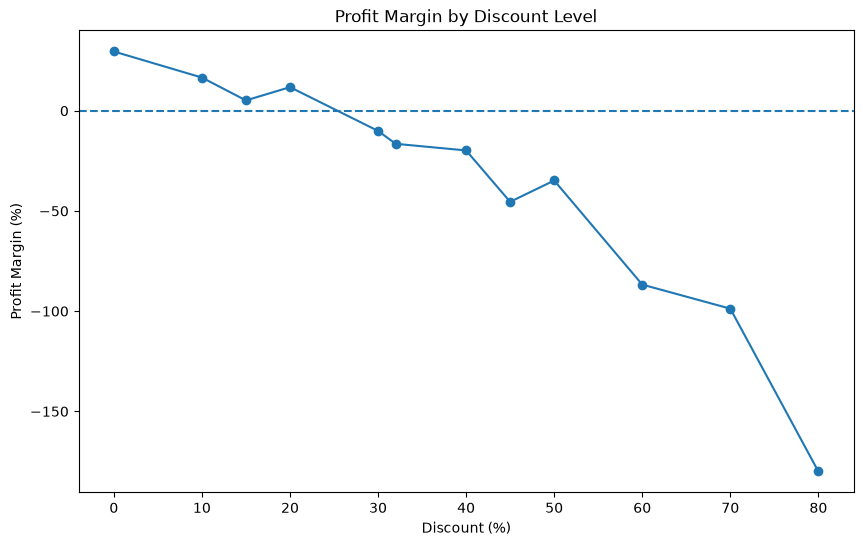

In [19]:
discount_profit = (
    df.groupby("Discount")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

discount_profit["Profit_Margin"] = (
    discount_profit["Profit"] /
    discount_profit["Sales"] * 100
)

plt.figure(figsize=(10, 6))
plt.plot(
    discount_profit["Discount"] * 100,
    discount_profit["Profit_Margin"],
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin by Discount Level")
plt.show()

In [20]:
import statsmodels.api as sm

X = df[["Discount", "Sales", "Quantity"]]
X = sm.add_constant(X)

y = df["Profit"]

model_multi = sm.OLS(y, X).fit()

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1287.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:20:17   Log-Likelihood:                -68371.
No. Observations:               10194   AIC:                         1.367e+05
Df Residuals:                   10190   BIC:                         1.368e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.4513      4.135      8.331      0.0

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[["Discount", "Sales", "Quantity"]].copy()
X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif


,Variable,VIF
0,const,4.447431
1,Discount,1.000947
2,Sales,1.041927
3,Quantity,1.041183


In [22]:
model_robust = sm.OLS(y, X).fit(cov_type="HC3")

print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     107.6
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           1.35e-68
Time:                        23:27:30   Log-Likelihood:                -68371.
No. Observations:               10194   AIC:                         1.367e+05
Df Residuals:                   10190   BIC:                         1.368e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.4513      5.412      6.366      0.0

In [23]:
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Month", "Sales"]

monthly_sales.head()

,Month,Sales
0,2023-01-31,14518.055
1,2023-02-28,4519.892
2,2023-03-31,56933.909
3,2023-04-30,28295.345
4,2023-05-31,26319.767


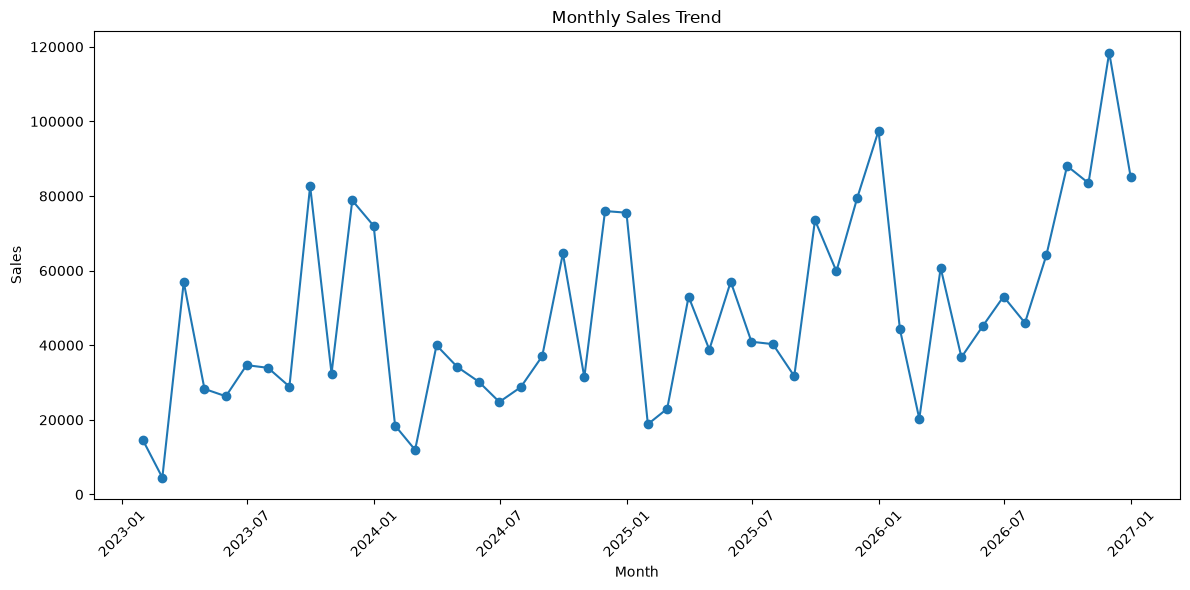

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
yearly_sales = (
    df.groupby(df["Order Date"].dt.year)["Sales"]
      .sum()
      .reset_index()
)

yearly_sales.columns = ["Year", "Sales"]

yearly_sales


,Year,Sales
0,2023,494040.2121
1,2024,472993.0310
2,2025,613933.5800
3,2026,745567.5312


In [26]:
monthly_sales["Month_Number"] = monthly_sales["Month"].dt.month

seasonality = (
    monthly_sales
    .groupby("Month_Number")["Sales"]
    .agg(["mean", "median"])
    .round(2)
)

seasonality

,mean,median
Month_Number,,
1,24017.38,18646.12
2,14937.81,16126.27
3,52668.02,54982.49
4,34524.69,35487.12
5,39691.26,37701.21
6,38365.00,37803.31
7,37250.43,37123.45
8,40455.48,34386.91
9,77220.92,78096.05


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

train = monthly_sales.iloc[:-12].copy()
test = monthly_sales.iloc[-12:].copy()

test["Naive_Forecast"] = train["Sales"].iloc[-1]

mae = mean_absolute_error(test["Sales"], test["Naive_Forecast"])
rmse = np.sqrt(mean_squared_error(test["Sales"], test["Naive_Forecast"]))

print("Naive MAE:", round(mae, 2))
print("Naive RMSE:", round(rmse, 2))

Naive MAE: 38863.69
Naive RMSE: 43964.2


In [2]:
import pandas as pd

df = pd.read_csv("../data/superstore_sales.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Month", "Sales"]

print("Monthly observations:", len(monthly_sales))
print(monthly_sales.head())

Monthly observations: 48
       Month      Sales
0 2023-01-31  14518.055
1 2023-02-28   4519.892
2 2023-03-31  56933.909
3 2023-04-30  28295.345
4 2023-05-31  26319.767


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

train = monthly_sales.iloc[:-12].copy()
test = monthly_sales.iloc[-12:].copy()

model_hw = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

test["HW_Forecast"] = model_hw.forecast(len(test))

mae_hw = mean_absolute_error(
    test["Sales"],
    test["HW_Forecast"]
)

rmse_hw = np.sqrt(
    mean_squared_error(
        test["Sales"],
        test["HW_Forecast"]
    )
)

print("Holt-Winters MAE:", round(mae_hw, 2))
print("Holt-Winters RMSE:", round(rmse_hw, 2))

Holt-Winters MAE: 11384.72
Holt-Winters RMSE: 12865.34


In [1]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["Month"],
    test["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test["Month"],
    test["HW_Forecast"],
    marker="o",
    label="Holt-Winters Forecast"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Holt-Winters Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [2]:
import matplotlib.pyplot as plt

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["Month"],
    test["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test["Month"],
    test["HW_Forecast"],
    marker="o",
    label="Holt-Winters Forecast"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Holt-Winters Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'test' is not defined

<Figure size 1200x600 with 0 Axes>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Load the dataset
df = pd.read_csv("../data/superstore_sales.csv")

# 2. Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# 3. Create monthly sales
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Month", "Sales"]

# 4. Split into training and test data
train = monthly_sales.iloc[:-12].copy()
test = monthly_sales.iloc[-12:].copy()

# 5. Fit Holt-Winters model
model_hw = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# 6. Forecast the test period
test["HW_Forecast"] = model_hw.forecast(len(test))

# 7. Calculate accuracy
mae_hw = mean_absolute_error(
    test["Sales"],
    test["HW_Forecast"]
)

rmse_hw = np.sqrt(
    mean_squared_error(
        test["Sales"],
        test["HW_Forecast"]
    )
)

print("Holt-Winters MAE:", round(mae_hw, 2))
print("Holt-Winters RMSE:", round(rmse_hw, 2))

Holt-Winters MAE: 11384.72
Holt-Winters RMSE: 12865.34


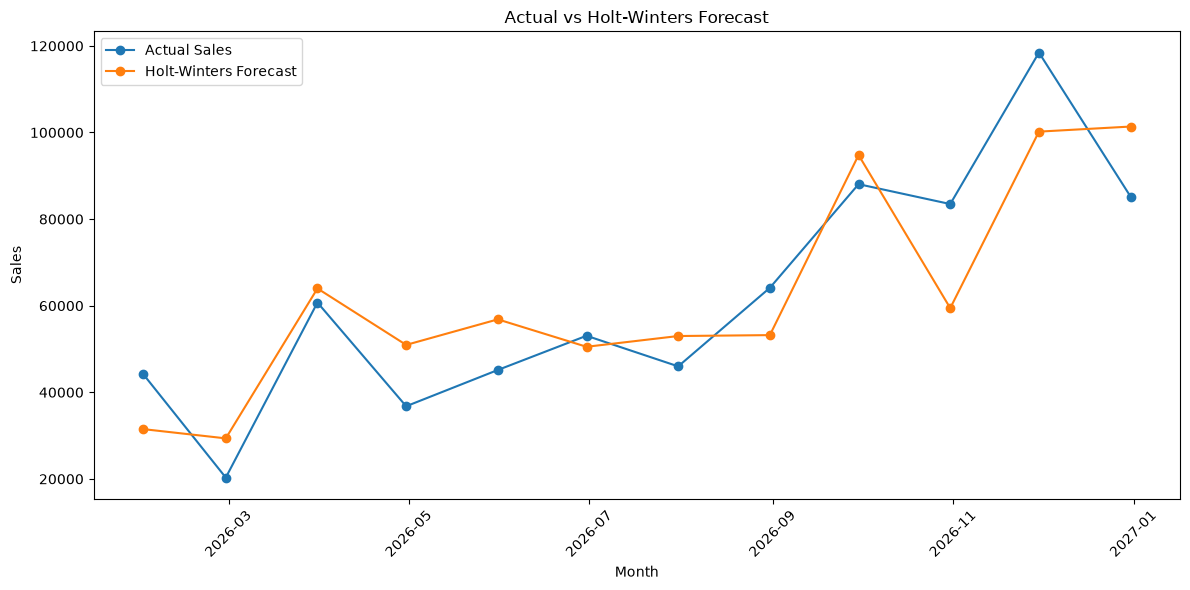

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["Month"],
    test["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test["Month"],
    test["HW_Forecast"],
    marker="o",
    label="Holt-Winters Forecast"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Holt-Winters Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1]:
plt.plot(
    test["Month"],
    test["HW_Forecast"],
    marker="o",
    label="Holt-Winters Forecast"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Holt-Winters Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

Holt-Winters MAE: 11384.72
Holt-Winters RMSE: 12865.34


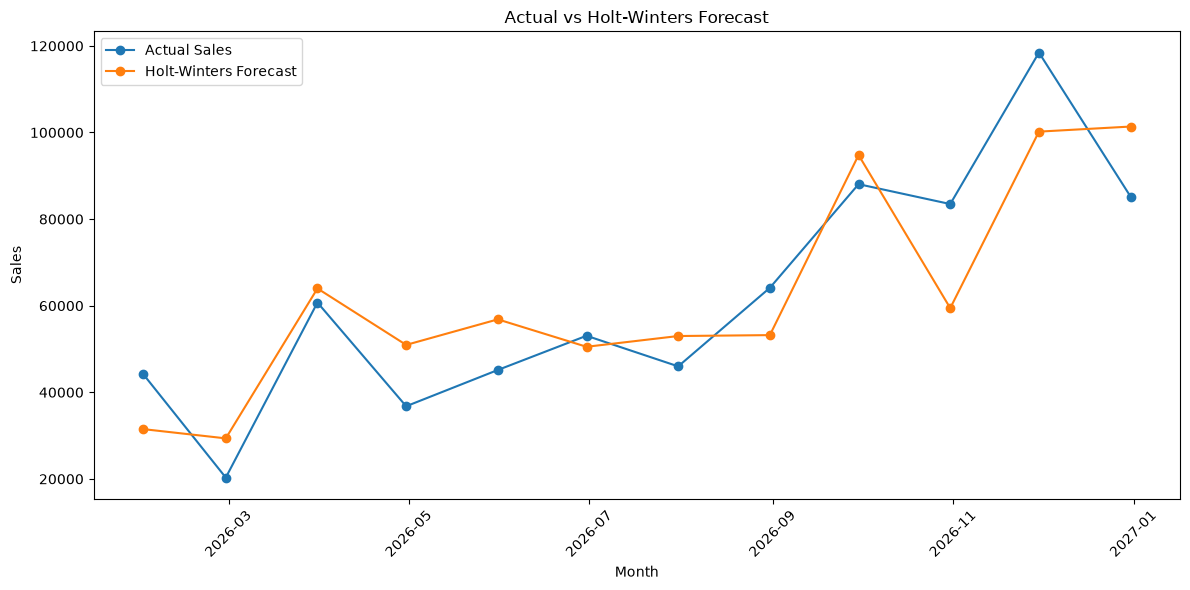

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Load the original dataset
df = pd.read_csv("../data/superstore_sales.csv")

# 2. Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# 3. Create monthly sales time series
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Month", "Sales"]

# 4. Split data:
#    First 36 months = training
#    Last 12 months = testing
train = monthly_sales.iloc[:-12].copy()
test = monthly_sales.iloc[-12:].copy()

# 5. Build Holt-Winters model
model_hw = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# 6. Forecast the 12-month test period
test["HW_Forecast"] = model_hw.forecast(len(test))

# 7. Evaluate forecast accuracy
mae_hw = mean_absolute_error(
    test["Sales"],
    test["HW_Forecast"]
)

rmse_hw = np.sqrt(
    mean_squared_error(
        test["Sales"],
        test["HW_Forecast"]
    )
)

print("Holt-Winters MAE:", round(mae_hw, 2))
print("Holt-Winters RMSE:", round(rmse_hw, 2))

# 8. Plot actual vs forecast
plt.figure(figsize=(12, 6))

plt.plot(
    test["Month"],
    test["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test["Month"],
    test["HW_Forecast"],
    marker="o",
    label="Holt-Winters Forecast"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Holt-Winters Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
# Final Holt-Winters model using all available historical data

final_model = ExponentialSmoothing(
    monthly_sales["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

future_forecast = final_model.forecast(12)

future_dates = pd.date_range(
    start=monthly_sales["Month"].max() + pd.offsets.MonthEnd(1),
    periods=12,
    freq="ME"
)

forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Forecast_Sales": future_forecast.values
})

forecast_df["Forecast_Sales"] = forecast_df["Forecast_Sales"].round(2)

forecast_df

,Month,Forecast_Sales
0,2027-01-31,51139.85
1,2027-02-28,43083.29
2,2027-03-31,77512.39
3,2027-04-30,62985.24
4,2027-05-31,70405.37
5,2027-06-30,67039.66
6,2027-07-31,69126.03
7,2027-08-31,68886.41
8,2027-09-30,110330.55
9,2027-10-31,80147.94


In [4]:
forecast_df.to_csv(
    "../data/sales_forecast_12_months.csv",
    index=False
)

print("12-month forecast saved successfully.")

12-month forecast saved successfully.


In [1]:
# Create a combined historical + forecast dataset

historical = monthly_sales[["Month", "Sales"]].copy()

historical["Type"] = "Actual"
historical = historical.rename(columns={
    "Sales": "Value"
})

future = forecast_df[["Month", "Forecast_Sales"]].copy()

future["Type"] = "Forecast"
future = future.rename(columns={
    "Forecast_Sales": "Value"
})

combined_forecast = pd.concat(
    [historical, future],
    ignore_index=True
)

combined_forecast.to_csv(
    "../data/historical_and_forecast_sales.csv",
    index=False
)

print("Combined forecast file saved.")

NameError: name 'monthly_sales' is not defined

In [2]:
import pandas as pd

# Load the historical superstore data
df = pd.read_csv("../data/superstore_sales.csv")

# Ensure Order Date is datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create monthly aggregated sales
df["Month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

# Load the forecast dataset
forecast_df = pd.read_csv("../data/sales_forecast_12_months.csv")

# Prepare historical data
historical = monthly_sales[["Month", "Sales"]].copy()
historical["Type"] = "Actual"
historical = historical.rename(columns={"Sales": "Value"})

# Prepare forecast data
future = forecast_df[["Month", "Forecast_Sales"]].copy()
future["Type"] = "Forecast"
future = future.rename(columns={"Forecast_Sales": "Value"})

# Combine historical and forecast datasets
combined_forecast = pd.concat([historical, future], ignore_index=True)

# Save the combined file
combined_forecast.to_csv(
    "../data/historical_and_forecast_sales.csv", index=False
)

print("Combined forecast file saved successfully.")

Combined forecast file saved successfully.
